In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
CASH = 10 ** 4
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [4]:
# метрика лосса: mae где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями
def loss_mae(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += abs((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0])
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=CASH, std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, CASH) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, CASH) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, CASH) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, CASH) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, CASH) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mae(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [ ]:
# само обучение
study = optuna.create_study(study_name="calibration_mae_2(10000)", direction="minimize", storage="sqlite:///calibration_mae_2(10000).db",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-29 22:43:07,737] A new study created in RDB with name: calibration_mae_2(10000)
Best trial: 0. Best value: 1.14603:   0%|          | 1/500 [00:16<2:14:23, 16.16s/it]

[I 2026-03-29 22:43:23,895] Trial 0 finished with value: 1.1460255868759557 and parameters: {'Random': 16, 'Fundamentalist': 21, 'Chartist': 7, 'Universalist': 28, 'MarketMaker': 0, 'Transaction_cost': 0.02257076651364182, 'Std': 1.1644367180933277, 'Std_Random': 1.7928123947945813, 'Avg_Traders': -1.8704823639697379, 'Last_Step': 0.14965539028378927, 'Last_Ret': 0.017401193997082426, 'Noisy_Level': 0.7903673671178246}. Best is trial 0 with value: 1.1460255868759557.


Best trial: 0. Best value: 1.14603:   0%|          | 2/500 [01:24<6:26:35, 46.58s/it]

[I 2026-03-29 22:44:31,767] Trial 1 finished with value: 7.804880440710324 and parameters: {'Random': 82, 'Fundamentalist': 26, 'Chartist': 46, 'Universalist': 80, 'MarketMaker': 1, 'Transaction_cost': 0.03266653857745679, 'Std': 0.9486542605072023, 'Std_Random': 0.13496441994592603, 'Avg_Traders': -2.281028421977855, 'Last_Step': 0.6010929794715368, 'Last_Ret': 0.6653644704320141, 'Noisy_Level': 3.3762491187595223}. Best is trial 0 with value: 1.1460255868759557.


Best trial: 0. Best value: 1.14603:   1%|          | 3/500 [01:47<4:57:53, 35.96s/it]

...

[I 2026-03-29 23:24:06,794] Trial 103 finished with value: 0.5271054084469271 and parameters: {'Random': 72, 'Fundamentalist': 27, 'Chartist': 87, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.0018684369765499837, 'Std': 1.3036387848563091, 'Std_Random': 0.198955616904565, 'Avg_Traders': -2.0199777528233347, 'Last_Step': 0.7718512197256948, 'Last_Ret': 0.029295155956254718, 'Noisy_Level': 0.010016399295068604}. Best is trial 85 with value: 0.32539443680828206.


Best trial: 85. Best value: 0.325394:  21%|██        | 105/500 [41:28<3:55:06, 35.71s/it]

[I 2026-03-29 23:24:35,705] Trial 104 finished with value: 0.46006029622733563 and parameters: {'Random': 71, 'Fundamentalist': 21, 'Chartist': 95, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.0018198740457144136, 'Std': 1.2465251162834696, 'Std_Random': 0.19406035179953093, 'Avg_Traders': -1.8583343757891257, 'Last_Step': 0.8510809503686751, 'Last_Ret': 0.034239153697299345, 'Noisy_Level': 0.005535208326904871}. Best is trial 85 with value: 0.32539443680828206.


Best trial: 85. Best value: 0.325394:  21%|██        | 106/500 [42:02<3:51:33, 35.26s/it]

[I 2026-03-29 23:25:10,054] Trial 105 finished with value: 0.4610676603454063 and parameters: {'Random': 71, 'Fundamentalist': 29, 'Chartist': 96, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.001585290290307507, 'Std': 1.1998929831368066, 'Std_Random': 0.2197991587093258, 'Avg_Traders': -1.8404579543785273, 'Last_Step': 0.8352783213120745, 'Last_Ret': 0.029674182672311686, 'Noisy_Level': 0.005528469536359853}. Best is trial 85 with value: 0.32539443680828206.


[I 2026-03-30 11:24:37,422] Using an existing study with name 'calibration_mae_2(10000)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_11204\2588289370.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


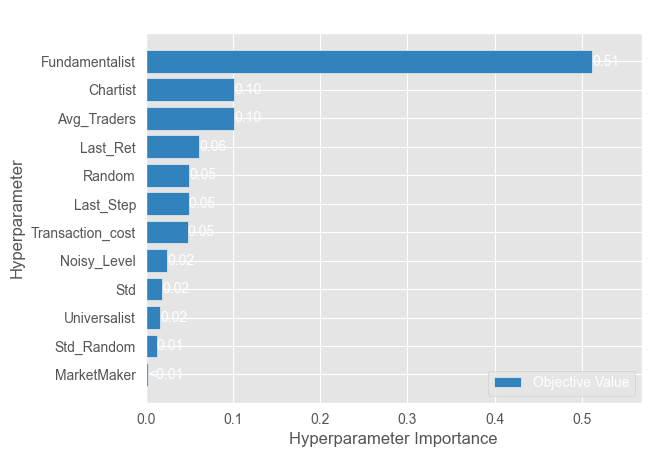

In [3]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study = optuna.create_study(study_name="calibration_mae_2(10000)", direction="minimize", storage="sqlite:///calibration_mae_2(10000).db",  load_if_exists=True)
plot_param_importances(study)
plt.show()

In [4]:
best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

Best params: {'Random': 78, 'Fundamentalist': 10, 'Chartist': 100, 'Universalist': 22, 'MarketMaker': 1, 'Transaction_cost': 0.0020496342627994647, 'Std': 2.4388231589036553, 'Std_Random': 0.28065549782486, 'Avg_Traders': -1.787802664068108, 'Last_Step': 0.8613021591166775, 'Last_Ret': 0.006204210293653703, 'Noisy_Level': 0.003209011086396602}
Best Score: 0.2668501527943686
